# EDA 

### Import thư viện

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
import joblib
import os
import math
from sklearn.preprocessing import RobustScaler

### Cấu hình hiển thị pandas:

In [33]:

pd.set_option("display.max_rows", None)       # Hiển thị toàn bộ số dòng
pd.set_option("display.max_columns", None)    # Hiển thị toàn bộ số cột
pd.set_option("display.max_colwidth", None)   # Hiển thị toàn bộ nội dung chuỗi
pd.set_option("display.width", None)          # Tăng độ rộng bảng hiển thị

### Mô tả tổng quan dữ liệu

In [34]:
# Đọc dữ liệu
df = pd.read_csv("C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\train .csv")
## ==============================
# 1. Số dòng, số cột và danh sách cột
# ==============================
summary_table = pd.DataFrame({
    "Số dòng": [df.shape[0]],
    "Số cột": [df.shape[1]],
    "Danh sách cột": [df.columns.tolist()]
})

print("=== THỐNG TIN TỔNG QUAN ===")
display(summary_table)

# ==============================
# 2. Bảng giá trị thiếu
# ==============================
missing_table = df.isnull().sum().reset_index()
missing_table.columns = ["Cột", "Số giá trị thiếu"]
missing_table = missing_table[missing_table["Số giá trị thiếu"] > 0]

print("\n=== BẢNG GIÁ TRỊ THIẾU ===")
# Thống kê số lượng giá trị thiếu theo từng cột
missing_table = df.isnull().sum().reset_index()
missing_table.columns = ["Tên cột", "Số giá trị thiếu"]

# Tính thêm tỷ lệ phần trăm thiếu
missing_table["Tỷ lệ thiếu (%)"] = (missing_table["Số giá trị thiếu"] / len(df)) * 100

# Chỉ hiển thị các cột có giá trị thiếu
missing_table = missing_table[missing_table["Số giá trị thiếu"] > 0]

# Sắp xếp giảm dần theo số lượng thiếu
missing_table = missing_table.sort_values(by="Số giá trị thiếu", ascending=False)

# Hiển thị bảng đầy đủ
print("=== THỐNG KÊ GIÁ TRỊ THIẾU ===")
print(missing_table.to_string(index=False, float_format="%.2f"))

# ==============================
# 3. Thống kê mô tả cho biến số (numeric)
# ==============================
describe_numeric = df.describe().transpose()

print("\n=== THỐNG KÊ MÔ TẢ – BIẾN SỐ ===")
display(describe_numeric)

# ==============================
# 4. Thống kê mô tả cho biến object
# ==============================
describe_object = df.describe(include="object").transpose()

print("\n=== THỐNG KÊ MÔ TẢ – BIẾN CHUỖI ===")
display(describe_object)

# ==============================
# 5. Bảng kiểu dữ liệu từng cột
# ==============================
dtype_table = pd.DataFrame({
    "Cột": df.columns,
    "Kiểu dữ liệu": df.dtypes.astype(str)
})

print("\n=== KIỂU DỮ LIỆU CÁC CỘT ===")
display(dtype_table)

=== THỐNG TIN TỔNG QUAN ===


,Số dòng,Số cột,Danh sách cột
0,14396,18,"[Id, Artist Name, Track Name, Popularity, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_in min/ms, time_signature, Class]"



=== BẢNG GIÁ TRỊ THIẾU ===
=== THỐNG KÊ GIÁ TRỊ THIẾU ===
         Tên cột  Số giá trị thiếu  Tỷ lệ thiếu (%)
instrumentalness              3541            24.60
             key              1609            11.18
      Popularity               333             2.31

=== THỐNG KÊ MÔ TẢ – BIẾN SỐ ===


,count,mean,std,min,25%,50%,75%,max
Id,14396.0,7198.500000,4155.911573,1.000000,3599.750000,7198.50000,10797.25000,14396.000
Popularity,14063.0,44.525208,17.418940,1.000000,33.000000,44.00000,56.00000,100.000
danceability,14396.0,0.543105,0.165517,0.059600,0.432000,0.54500,0.65800,0.989
energy,14396.0,0.662422,0.235967,0.001210,0.508000,0.69900,0.86100,1.000
key,12787.0,5.953781,3.200013,1.000000,3.000000,6.00000,9.00000,11.000
loudness,14396.0,-7.900852,4.057362,-39.952000,-9.538000,-7.01350,-5.16200,1.342
mode,14396.0,0.640247,0.479944,0.000000,0.000000,1.00000,1.00000,1.000
speechiness,14396.0,0.080181,0.085157,0.022500,0.034800,0.04710,0.08310,0.955
acousticness,14396.0,0.246746,0.310922,0.000000,0.004280,0.08145,0.43225,0.996
instrumentalness,10855.0,0.178129,0.304266,0.000001,0.000088,0.00392,0.20100,0.996



=== THỐNG KÊ MÔ TẢ – BIẾN CHUỖI ===


,count,unique,top,freq
Artist Name,14396,7913,Backstreet Boys,58
Track Name,14396,12455,Fire,8



=== KIỂU DỮ LIỆU CÁC CỘT ===


,Cột,Kiểu dữ liệu
Id,Id,int64
Artist Name,Artist Name,object
Track Name,Track Name,object
Popularity,Popularity,float64
danceability,danceability,float64
energy,energy,float64
key,key,float64
loudness,loudness,float64
mode,mode,int64
speechiness,speechiness,float64


### Sơ bộ về data:

Các Vấn đề Sơ khởi Cần Xử lý
Dựa trên các bước bạn đã thực hiện (xử lý Missing Value và Outlier), các vấn đề sau là điển hình và đã được xử lý một cách hợp lý:

1. Missing Value (Giá trị thiếu)
instrumentalness (~24.6%): Tỷ lệ thiếu cao cho thấy nhiều bài hát bị đánh giá là không có phần nhạc cụ đáng kể.

Giải pháp đã thực hiện: Điền Median theo Class (Genre) là tối ưu.

key (~11.2%): Các bài hát không xác định được cao độ chính.

Giải pháp đã thực hiện: Điền bằng giá trị "Unknown" là phù hợp nhất cho biến phân loại.

Popularity (~2.3%): Tỷ lệ thiếu thấp, thường là bài chưa có đánh giá.

2. Outlier và Phân phối Lệch (Skewness):

Phần lớn các thuộc tính âm nhạc (như instrumentalness, acousticness, speechiness, duration) có phân phối lệch phải (Right-skewed, tập trung nhiều ở giá trị gần $0$).

Lý do: Đa số nhạc pop/thương mại có lời (instrumentalness gần 0), có ít lời nói (speechiness gần 0), và có thời lượng trung bình.

3. Chuẩn hóa và Mã hóa (Normalization & Encoding)

Sự khác biệt về thang đo: Các cột có thang đo khác nhau (ví dụ: danceability $[0, 1]$, tempo $[50, 200]$, loudness $[ -30, 0]$).

Biến Phân loại: Các cột key, mode, time_signature cần được chuyển đổi.

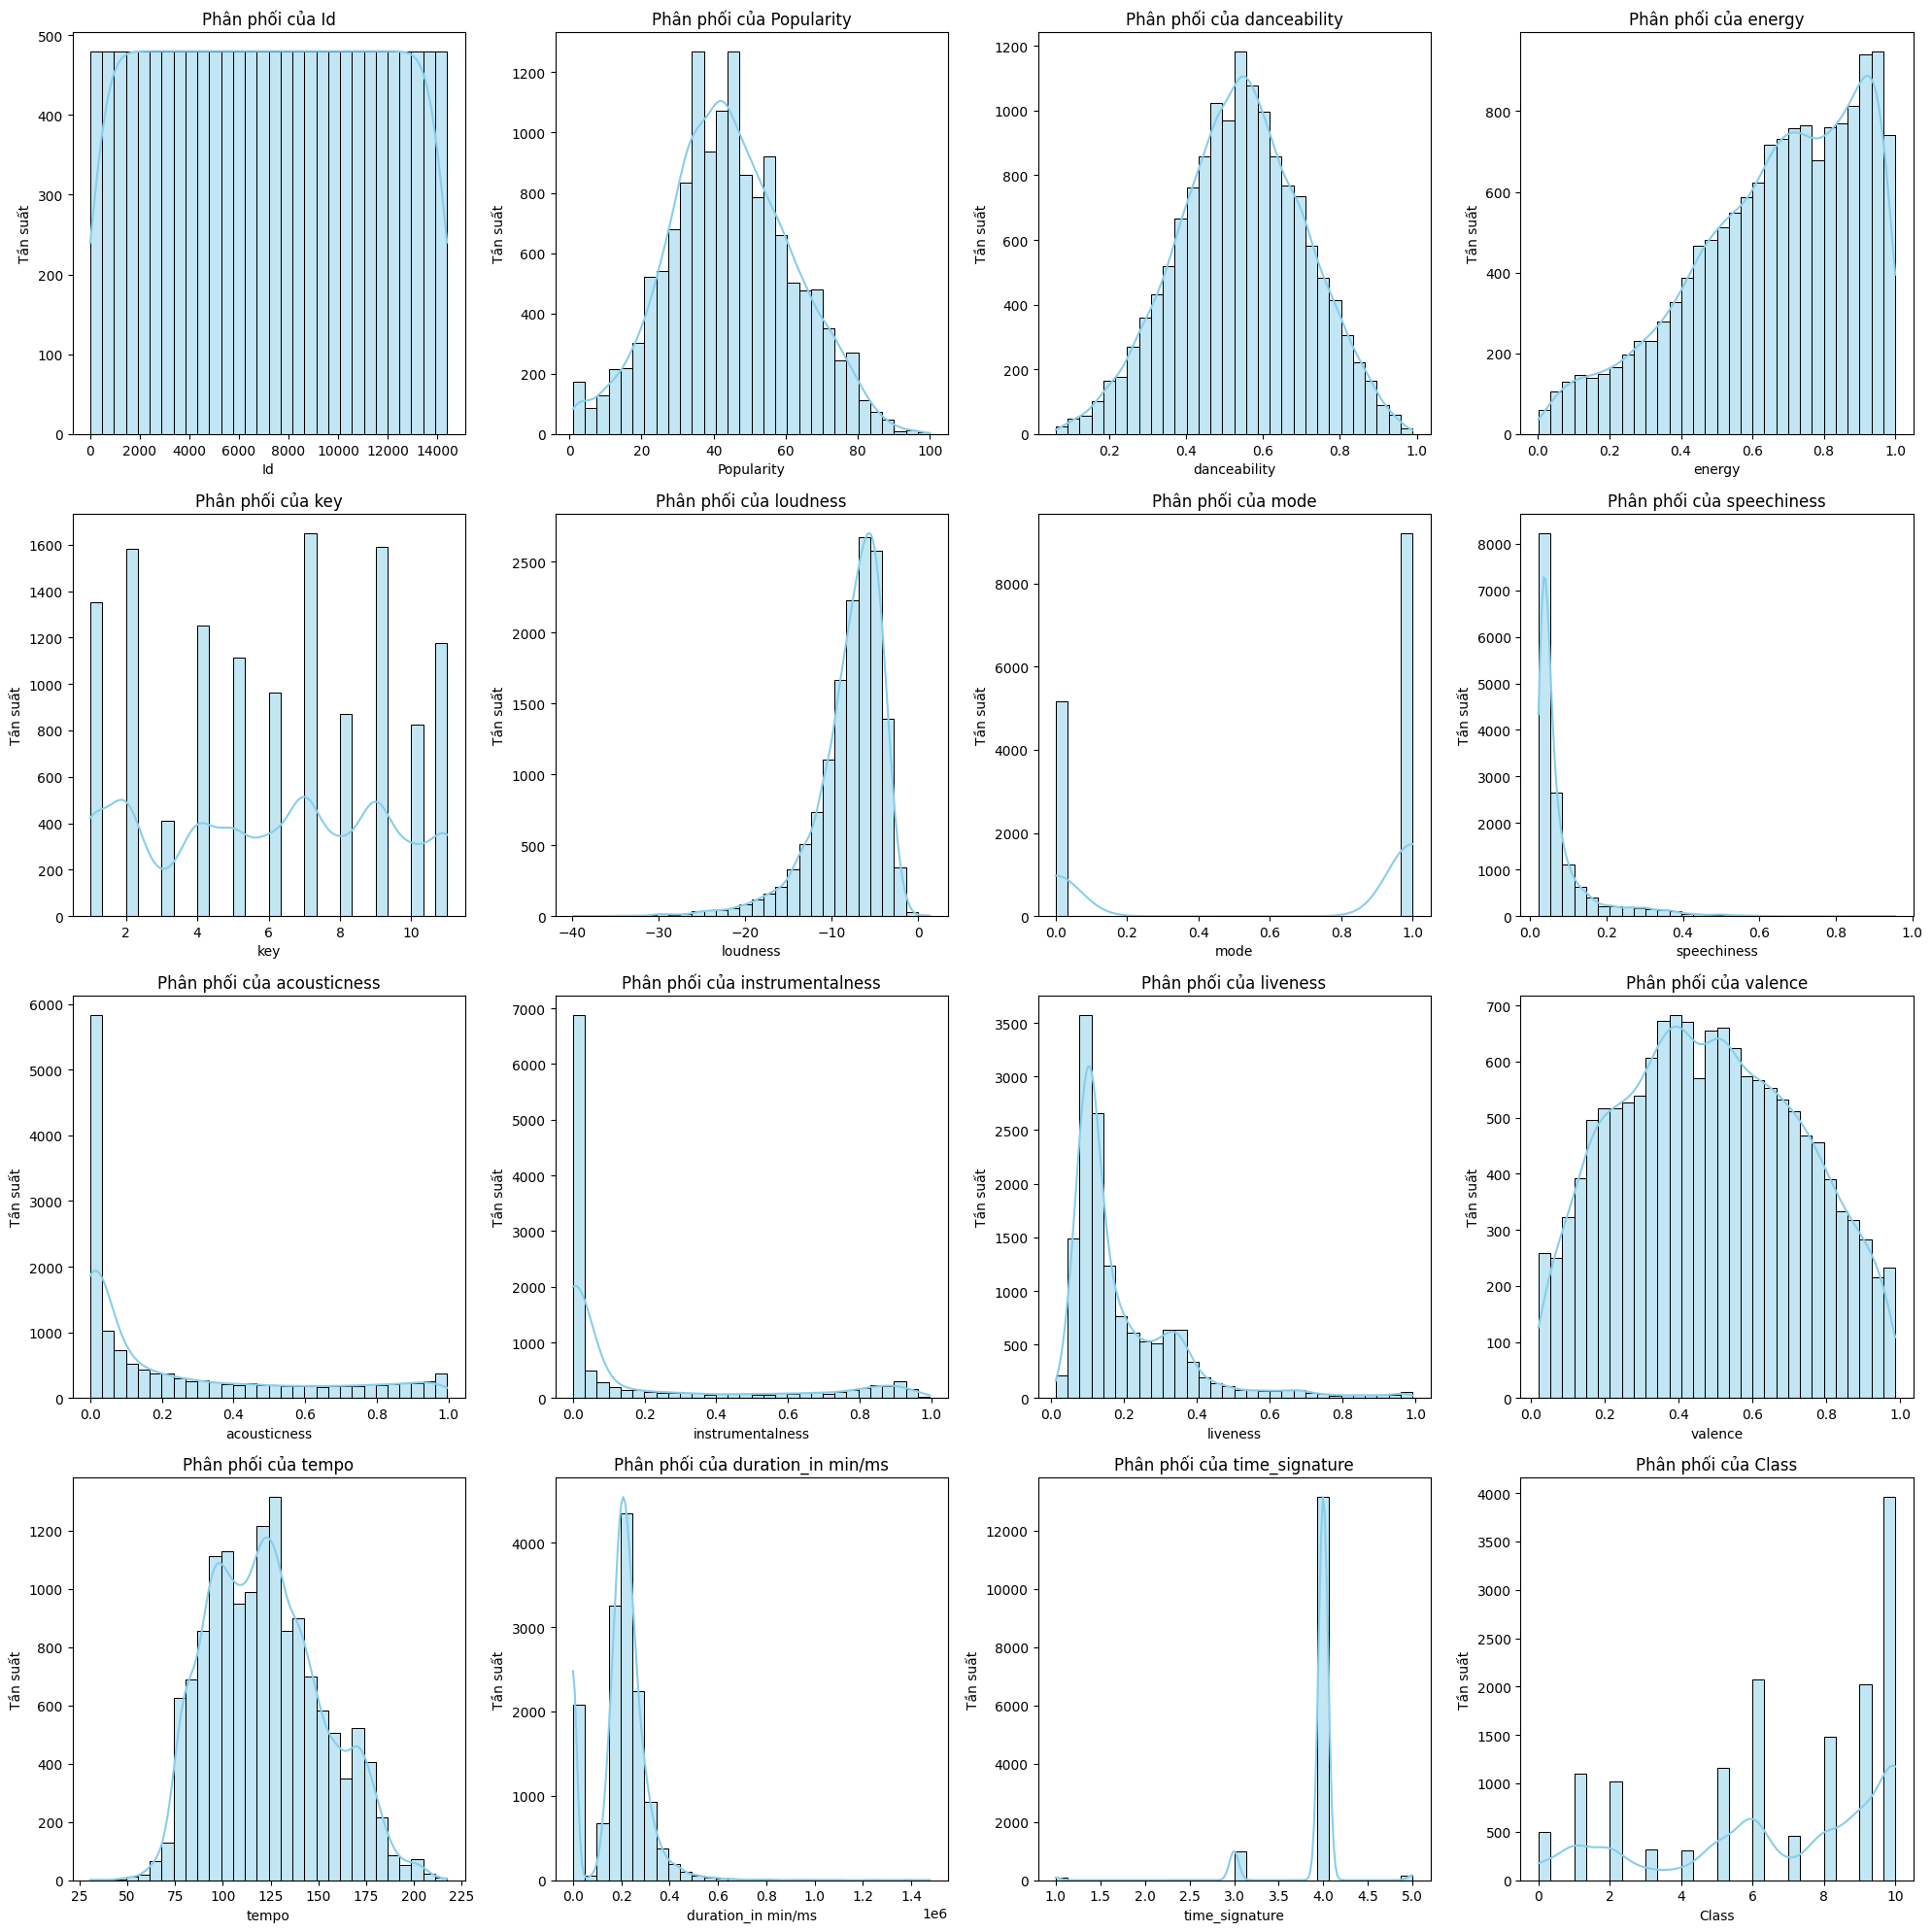

In [35]:
# Lấy danh sách các biến số
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Thiết lập lưới subplot
n_cols = 4  # số cột trong lưới
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Vẽ từng biểu đồ vào subplot
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Phân phối của {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")

# Ẩn các subplot dư nếu có
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


1. Phân phối tổng quát
Phần lớn các đặc trưng có phân phối lệch (skewed), không phải chuẩn. Điều này ảnh hưởng đến việc chọn mô hình và kỹ thuật chuẩn hóa.

Một số biến có phân phối gần đều hoặc chuẩn, ví dụ: danceability, energy, valence.

Các biến như instrumentalness, acousticness, speechiness có phân phối lệch mạnh về phía thấp → nhiều bài hát gần như không có đặc trưng này.

2. Nhận xét theo từng đặc trưng
 Biến âm nhạc (0–1)
danceability: phân phối khá đều, tập trung quanh 0.65 → phù hợp với nhạc pop, dance.

energy: lệch nhẹ về cao → nhiều bài có năng lượng mạnh.

speechiness: rất thấp → phần lớn bài không có lời nói rõ ràng (ít rap).

acousticness: lệch về thấp → phần lớn bài không phải nhạc mộc.

instrumentalness: rất nhiều giá trị gần 0 → đa số bài có lời.

valence: phân phối khá đều → cảm xúc tích cực không quá thiên lệch.

 Biến âm lượng và tốc độ
loudness: phân phối lệch trái, nhiều bài có âm lượng thấp → cần chuẩn hóa.

tempo: phân phối rộng, có nhiều bài rất nhanh → có thể ảnh hưởng đến phân loại.

 Biến nhịp và mode
key, mode, time_signature: phân phối rời rạc → nên xử lý bằng one-hot hoặc embedding.

 Biến thời lượng
duration_in_minims: có outlier → một số bài rất dài, cần xử lý để tránh ảnh hưởng mô hình.

 Popularity
Phân phối lệch phải → nhiều bài ít phổ biến, một số rất nổi bật → có thể ảnh hưởng đến nhãn nếu dùng.

 Class
Phân phối Class khá đều, không quá mất cân bằng → thuận lợi cho huấn luyện mô hình.


Phân phối lệch -> Dùng log-transform hoặc robust scaler

Biến rời rạc ->	One-hot hoặc embedding

Outlier ->	Cắt ngưỡng hoặc dùng robust model

Dữ liệu thiếu ->	Tùy thuộc vào kiểu dữ liệu, tính chất dữ liệu thiếu mà đưa ra phương pháp


=== PHÂN BỐ CLASS ===
Class
0      500
1     1098
2     1018
3      322
4      310
5     1157
6     2069
7      461
8     1483
9     2019
10    3959


C:\Users\hienm\AppData\Local\Temp\ipykernel_25692\3483057406.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y=feature, data=avg_values, palette="Set2", ax=axes[i])
C:\Users\hienm\AppData\Local\Temp\ipykernel_25692\3483057406.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y=feature, data=avg_values, palette="Set2", ax=axes[i])
C:\Users\hienm\AppData\Local\Temp\ipykernel_25692\3483057406.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y=feature, data=avg_values, palette="Set2", ax=axes[i])
C:\U

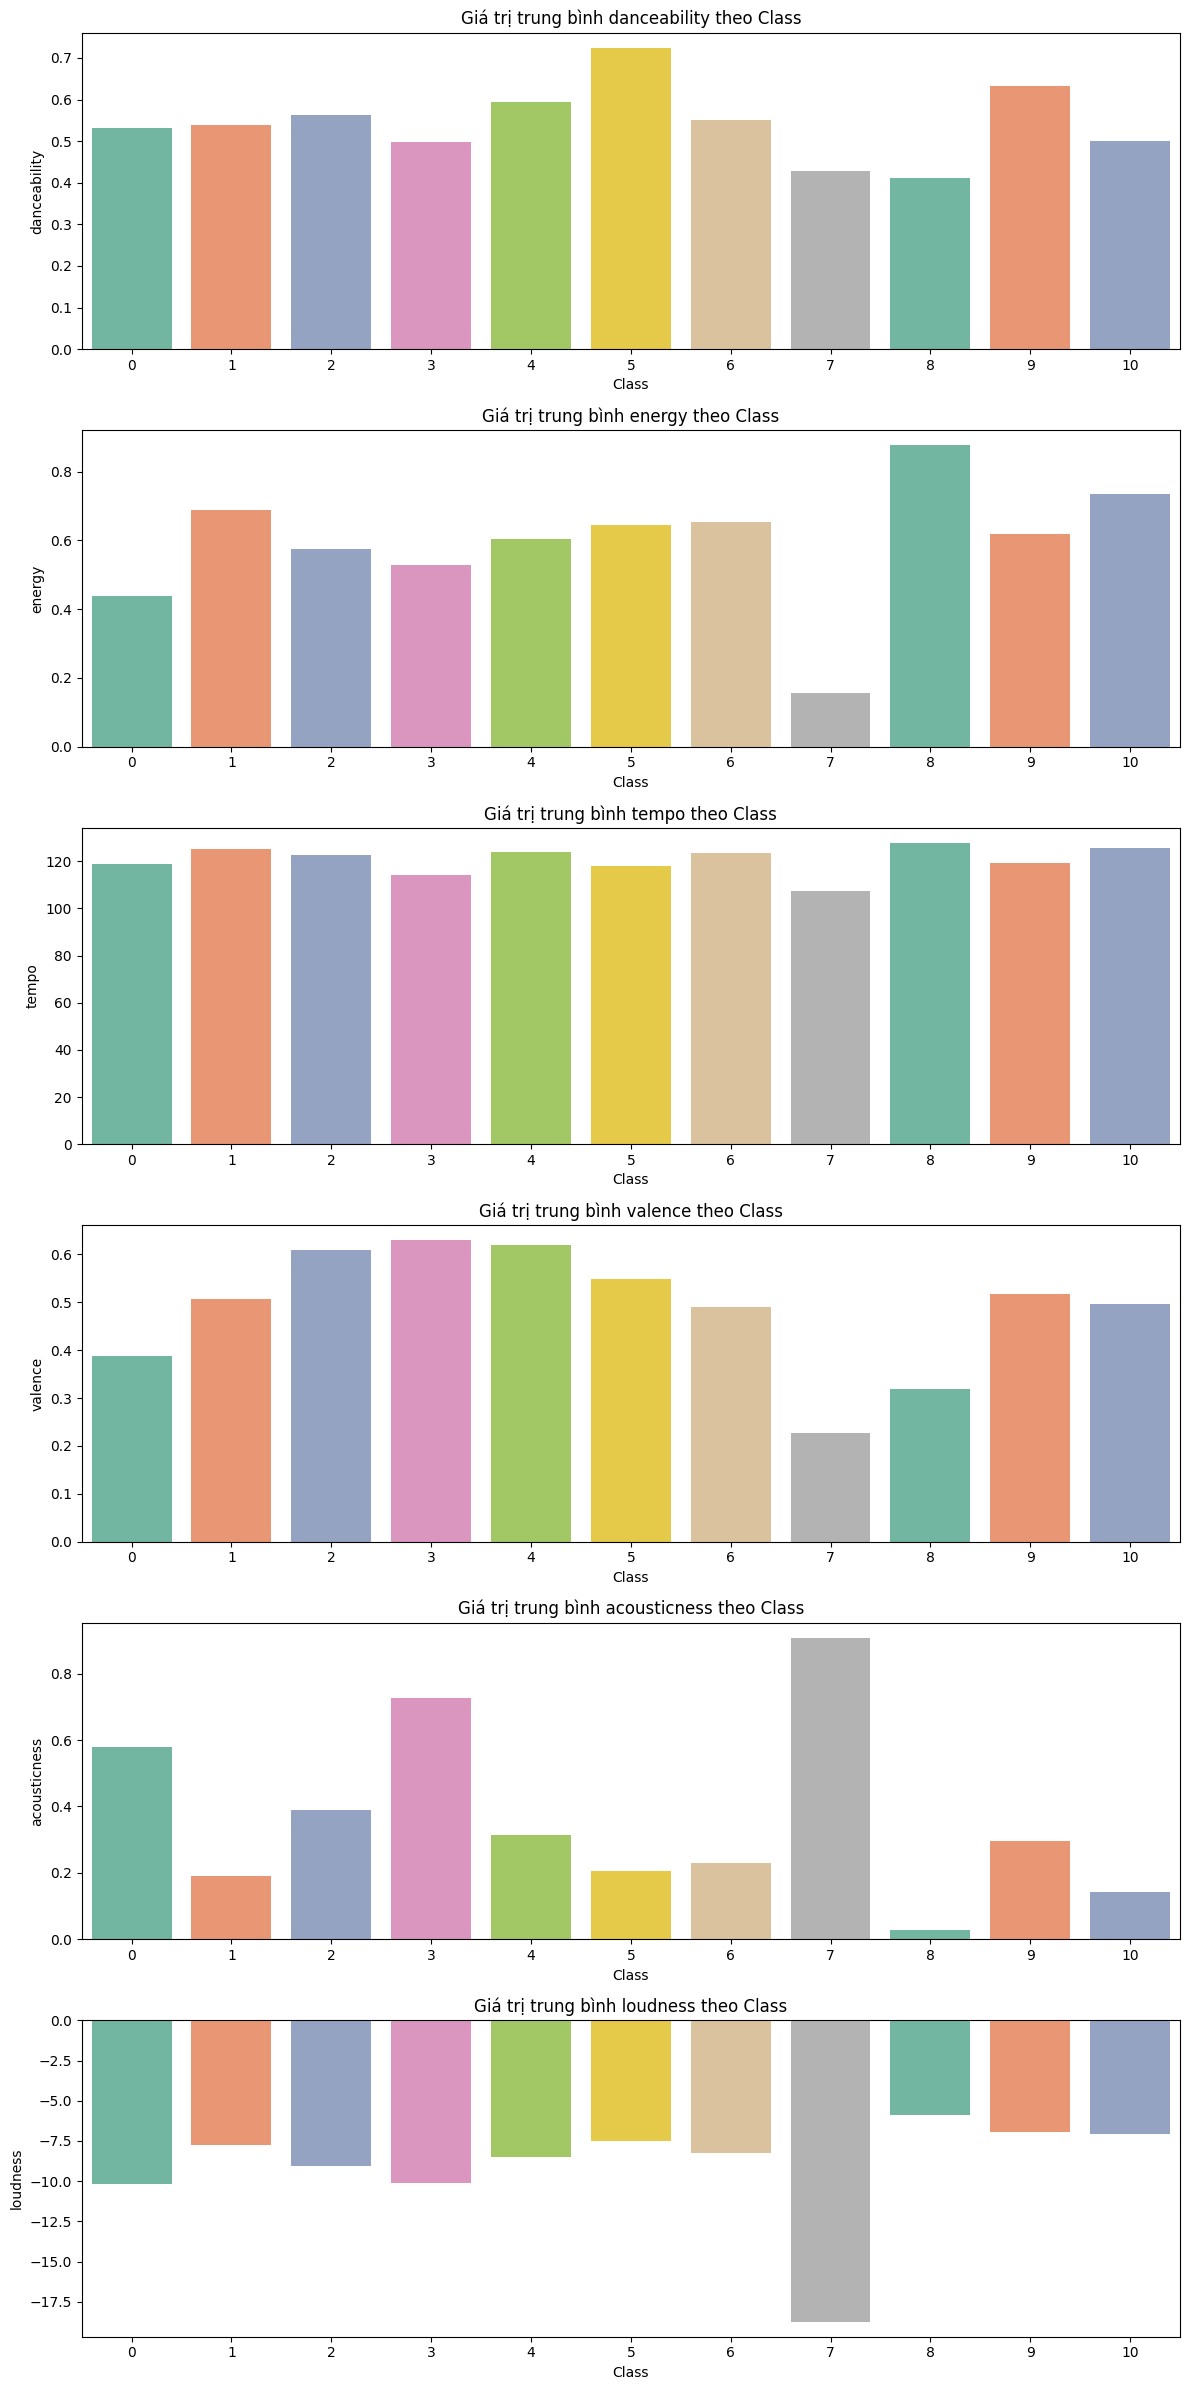

In [36]:
# Đếm số lượng bài hát theo Class
class_counts = df["Class"].value_counts().sort_index()

print("\n=== PHÂN BỐ CLASS ===")
print(class_counts.to_string())
# Các đặc trưng muốn phân tích
features = ["danceability", "energy", "tempo", "valence", "acousticness", "loudness"]

# Thiết lập lưới subplot
fig, axes = plt.subplots(len(features), 1, figsize=(12, 4 * len(features)))

# Vẽ bar chart cho từng đặc trưng theo Class
for i, feature in enumerate(features):
    avg_values = df.groupby("Class")[feature].mean().reset_index()
    sns.barplot(x="Class", y=feature, data=avg_values, palette="Set2", ax=axes[i])
    axes[i].set_title(f"Giá trị trung bình {feature} theo Class")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

 1. danceability theo Class
Một số Class như Class 8 và Class 10 có giá trị danceability cao hơn → thể loại nhạc dễ nhảy, có thể là pop hoặc dance.

Class 4 và Class 6 thấp hơn → có thể là nhạc cổ điển hoặc ballad, ít nhịp điệu.

 2. energy theo Class
Class 10 nổi bật với energy cao nhất → có thể là rock, EDM, hoặc nhạc mạnh.

Class 2 và Class 4 thấp hơn → thiên về nhạc nhẹ, mộc hoặc thư giãn.

 3. tempo theo Class
Class 5 và Class 10 có tempo cao → nhạc nhanh, sôi động.

Class 4 và Class 6 có tempo thấp → nhạc chậm, có thể là ballad hoặc acoustic.

 4. valence theo Class
Class 8 và Class 10 có valence cao → nhạc vui vẻ, tích cực.

Class 2 và Class 4 thấp hơn → nhạc buồn, u sầu hoặc sâu lắng.

 5. acousticness theo Class
Class 2 và Class 4 có acousticness cao → nhạc mộc, cổ điển, ít xử lý điện tử.

Class 10 và Class 8 thấp → nhạc điện tử, hiện đại.

 6. loudness theo Class
Class 10 có loudness cao nhất → nhạc mạnh, có thể là rock hoặc EDM.

Class 2 và Class 4 thấp hơn → nhạc nhẹ, ít âm lượng.


Class 10: Năng lượng cao, tempo nhanh, âm lượng lớn → có thể là EDM, rock

Class 2 & 4	: Acousticness cao, energy thấp, valence thấp → có thể là nhạc cổ điển, ballad

Class 8: Danceability và valence cao → nhạc pop, vui vẻ

Class 5: Tempo cao → có thể là nhạc dance hoặc techno

### Tổng quan và hướng giải quyết missing value:



instrumentalness   ----- 	24.60%  -----	Một số bài không có phần nhạc cụ rõ ràng

key -----	11.18%  -----	Một số bài không xác định được nhịp hoặc mode

Popularity  -----	2.31%	-----    Thiếu ở bài chưa được đánh giá hoặc chưa phát hành rộng rãi

---------------------------------
### Hướng giải quyết

Phân tích từng biến
1. instrumentalness (thiếu ~24.6%)
Đặc điểm: giá trị nằm trong khoảng [0–1], phân phối lệch mạnh về 0 → đa số bài hát có lời.

Ý nghĩa: nếu bài hát có lời thì giá trị gần 0, nếu nhạc cụ thì cao hơn.

Chiến lược xử lý:

Không nên điền bằng median toàn cục vì phân phối lệch.

Điền bằng median theo Class: vì Class phản ánh thể loại nhạc, có sự khác biệt rõ ràng (ví dụ: Class cổ điển có instrumentalness cao hơn pop).

Nếu Class không đủ phân biệt → điền bằng 0 (mặc định “có lời”).

 Phù hợp nhất: median theo Class.

2. key (thiếu ~11.2%)
Đặc điểm: biến rời rạc (0–11), biểu thị cao độ chính của bài hát.

Ý nghĩa: một số bài không xác định được key → bản chất là “không có thông tin”.

Chiến lược xử lý:

Không nên điền bằng median hoặc mode toàn cục vì sẽ làm sai lệch phân phối.

Điền bằng giá trị đặc biệt "Unknown" để giữ lại thông tin rằng bài hát không xác định được key.

Sau đó encode bằng One-hot hoặc Embedding để mô hình hiểu.

 Phù hợp nhất: điền "Unknown".

3. Popularity (thiếu ~2.3%)
Đặc điểm: giá trị liên tục [0–100], phân phối lệch phải (đa số bài ít phổ biến, một số rất nổi bật).

Ý nghĩa: phụ thuộc vào nhiều yếu tố như nghệ sĩ, thể loại, năng lượng, valence, danceability.

Chiến lược xử lý:

Vì tỷ lệ thiếu nhỏ, có thể điền bằng median.

Nhưng để chính xác hơn, có thể dự đoán bằng mô hình hồi quy (Random Forest hoặc KNN) dựa trên các đặc trưng khác và Class.

Nếu Popularity không dùng trong mô hình chính → có thể loại bỏ.

 Phù hợp nhất: dự đoán bằng mô hình hồi quy (Random Forest/KNN) nếu dùng trong huấn luyện; nếu không quan trọng → điền median.

--------------------------------
### Việc sẽ làm:



instrumentalness :	Điền median theo Class

key :	Điền "Unknown"

Popularity :	Dự đoán bằng mô hình hồi quy (Random Forest/KNN) hoặc median nếu đơn giản

In [37]:
# 1. Instrumentalness -> median theo Class
df["instrumentalness"] = df.groupby("Class")["instrumentalness"].transform(lambda x: x.fillna(x.median()))

# ==============================
# 2. Key -> Unknown
df["key"] = df["key"].astype("object")
df["key"] = df["key"].fillna("Unknown")

# ==============================
# 3. Popularity -> dự đoán bằng RandomForest
train_data = df[df["Popularity"].notnull()]
X_train = train_data[["energy", "valence", "danceability", "Class"]]
y_train = train_data["Popularity"]

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

missing_data = df[df["Popularity"].isnull()]
X_missing = missing_data[["energy", "valence", "danceability", "Class"]]
df.loc[df["Popularity"].isnull(), "Popularity"] = model.predict(X_missing)

# ==============================
# 4. Lưu file đã xử lý sang nơi khác
output_path = "C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_after_missing_value.csv"
df.to_csv(output_path, index=False)

print(f"File đã được lưu tại: {output_path}")

File đã được lưu tại: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challange3\data\data_afterfix\train_after_missing_value.csv


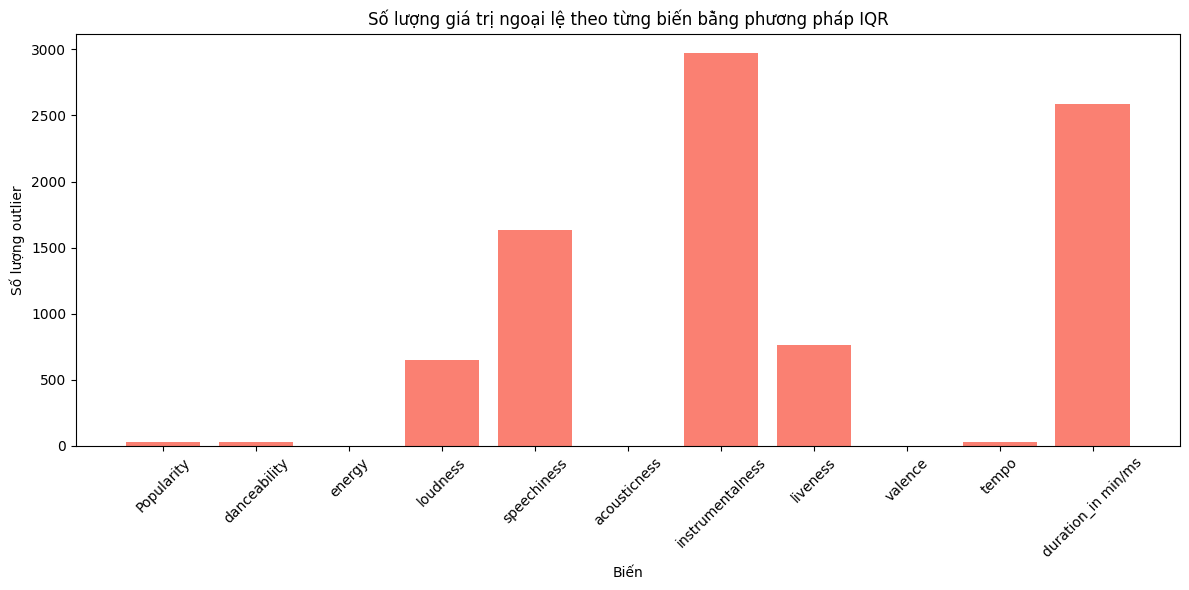

In [38]:
df = pd.read_csv("C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_after_missing_value.csv")

# Danh sách các biến liên tục cần kiểm tra ngoại lệ
continuous_vars = [
    "Popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_in min/ms"
]

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

outlier_counts = {col: count_outliers(df[col].dropna()) for col in continuous_vars}

plt.figure(figsize=(12,6))
plt.bar(outlier_counts.keys(), outlier_counts.values(), color="salmon")
plt.title("Số lượng giá trị ngoại lệ theo từng biến bằng phương pháp IQR")
plt.xlabel("Biến")
plt.ylabel("Số lượng outlier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ta dễ thấy một vài cột có lượng Outliner quá lớn, ta dễ thấy có các lý do sau: 

các đặc trưng âm nhạc thường có phân phối lệch (skewed) hoặc đa đỉnh (multimodal):

Duration (Thời lượng): Một bài hát Punk có thể chỉ dài 2 phút, trong khi một bản giao hưởng hoặc Progressive Rock có thể dài 15-20 phút. Nếu dùng IQR, bạn sẽ vô tình xóa sạch các bài nhạc cổ điển hoặc nhạc Trance dài, làm mất cân bằng dữ liệu.

Speechiness: Đa số các bài hát có giá trị này thấp. Tuy nhiên, Rap hoặc Hip-hop sẽ có giá trị rất cao. Nếu lọc outlier phía trên, bạn đang xóa sổ dòng nhạc Rap khỏi dataset.

Instrumentalness: Đây là dữ liệu cực kỳ phân cực. Phần lớn là 0 (có lời), một số ít là 1 (không lời). Các giá trị ở giữa rất ít. IQR sẽ hoạt động rất tệ với dạng phân phối nhị phân này.

--> Việc xử lí Outliner 1 cách trực tiếp bằng IQR là không được

In [39]:
df = pd.read_csv("C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_after_missing_value.csv")

# Giả sử đã thực hiện các bước xử lý Outlier và Missing Value
# Ví dụ đơn giản hóa:
df['duration_ms_standard_log'] = np.log1p(df['duration_in min/ms'])
df['loudness_capped'] = df['loudness'].fillna(df['loudness'].median())
df['key'] = df['key'].astype(object).fillna('Unknown')
df['mode'] = df['mode'].astype(object).fillna('Unknown')
df.dropna(subset=['Class'], inplace=True) # Loại bỏ dòng thiếu Class
# End of simple imputation/transformation example

print(f"Số lượng cột ban đầu: {df.shape[1]}")
print("-" * 50)


## BƯỚC 1: XỬ LÝ BIẾN PHÂN LOẠI (ENCODING)

# Các cột phân loại (Category) cần chuyển đổi thành số
categorical_cols = ['key', 'mode', 'time_signature']
# Loại bỏ Class (Target) và các cột định danh khác
cols_to_encode = [col for col in categorical_cols if col in df.columns]

# Sử dụng One-Hot Encoding cho các cột Category
# drop_first=True giúp tránh đa cộng tuyến (multicollinearity)
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print("BƯỚC 1: Hoàn thành One-Hot Encoding.")
print(f"Số lượng cột sau Encoding: {df.shape[1]}")
print("-" * 50)


## BƯỚC 2: CHUẨN HÓA DỮ LIỆU (ROBUST SCALING)

# Các cột không cần Scaling:
# 1. Target (Class)
# 2. Các cột định danh (Id, Artist Name, Track Name)
# 3. Các cột đã được One-Hot Encoding (chỉ chứa 0 và 1)

# Lấy danh sách các cột số còn lại để Scaling
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Loại bỏ cột Target (Class) và các cột đã xử lý khác
cols_to_scale = [
    col for col in numeric_cols 
    if col not in ['Class', 'Id'] and not col.startswith(('key_', 'mode_', 'time_signature_'))
]

# 1. Khởi tạo RobustScaler
scaler = RobustScaler()

# 2. Áp dụng Scaling cho các cột số
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("BƯỚC 2: Hoàn thành Robust Scaling.")
print("-" * 50)


## KẾT QUẢ CUỐI CÙNG
print("Dataframe sau khi hoàn thiện tiền xử lý:")
print(df.head())
print("\nCác cột đã được scale (ví dụ):")
print(df[['duration_ms_standard_log', 'loudness_capped']].describe().T)

df.to_csv('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_processed.csv', index=False)

C:\Users\hienm\AppData\Local\Temp\ipykernel_25692\757157963.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['mode'] = df['mode'].astype(object).fillna('Unknown')


Số lượng cột ban đầu: 20
--------------------------------------------------
BƯỚC 1: Hoàn thành One-Hot Encoding.
Số lượng cột sau Encoding: 32
--------------------------------------------------
BƯỚC 2: Hoàn thành Robust Scaling.
--------------------------------------------------
Dataframe sau khi hoàn thiện tiền xử lý:
   Id          Artist Name       Track Name  Popularity  danceability  \
0   1    Marina Maximilian       Not Afraid   -0.304348     -0.933628   
1   2       The Black Keys  Howlin' for You    1.000000      0.796460   
2   3  Royal & the Serpent          phuck u    0.268696      0.172566   
3   4   Detroit Blues Band      Missing You   -1.391304     -0.132743   
4   5         Coast Contra          My Lady    0.173913      0.088496   

     energy  loudness  speechiness  acousticness  instrumentalness  liveness  \
0 -0.461756  0.083295    -0.186335      0.692922         -0.025094 -0.144905   
1  0.135977  0.335580     0.838509     -0.126761          0.786367 -0.157505   


In [40]:
# --- 1. ĐỌC DỮ LIỆU ĐÃ XỬ LÝ (GIẢ ĐỊNH) ---
# Tên file phải là file đã xử lý Outlier và Missing Value
try:
    df = pd.read_csv('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_processed.csv') 
    print("Đã đọc file 'train_processed_final.csv' thành công.")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file đã xử lý. Đang sử dụng file gốc để minh họa.")
    # Nếu không tìm thấy, tạo các cột cần thiết cho minh họa
    df = pd.read_csv('train.csv')
    # Thêm các cột giả định đã xử lý để code FE chạy
    df['duration_ms_standard_log'] = np.log1p(df['duration_in min/ms'].fillna(200000))
    df['loudness_capped'] = df['loudness'].fillna(-7.0).clip(lower=df['loudness'].quantile(0.05), upper=df['loudness'].quantile(0.95))
    df['tempo_capped'] = df['tempo'].fillna(120).clip(lower=df['tempo'].quantile(0.05), upper=df['tempo'].quantile(0.95))
    df['acousticness_log'] = np.log1p(df['acousticness'].fillna(0.0))
    df['instrumentalness_log'] = np.log1p(df['instrumentalness'].fillna(0.0))
    df['speechiness_log'] = np.log1p(df['speechiness'].fillna(0.0))
    df['key'] = df['key'].astype(object).fillna('Unknown')
    df['mode'] = df['mode'].astype(object).fillna('Unknown')
    df['time_signature'] = df['time_signature'].astype(object).fillna(4)
    df = pd.get_dummies(df, columns=['key', 'mode', 'time_signature'], drop_first=True)
    df.rename(columns={'mode_1': 'mode_major'}, inplace=True)
    print("Sử dụng dữ liệu gốc và tạo các cột giả định để minh họa.")
    
# Loại bỏ các cột không cần thiết cho mô hình
df.drop(['Id', 'Artist Name', 'Track Name', 'duration_ms_standard'], axis=1, errors='ignore', inplace=True)

# Tạo các cột log-transformed nếu chưa tồn tại
if 'acousticness_log' not in df.columns:
    df['acousticness_log'] = np.log1p(df['acousticness'].fillna(0.0))
if 'instrumentalness_log' not in df.columns:
    df['instrumentalness_log'] = np.log1p(df['instrumentalness'].fillna(0.0))
if 'speechiness_log' not in df.columns:
    df['speechiness_log'] = np.log1p(df['speechiness'].fillna(0.0))
if 'duration_ms_standard_log' not in df.columns:
    df['duration_ms_standard_log'] = np.log1p(df['duration_in min/ms'].fillna(200000))
if 'loudness_capped' not in df.columns:
    df['loudness_capped'] = df['loudness'].fillna(df['loudness'].median())
if 'tempo_capped' not in df.columns:
    df['tempo_capped'] = df['tempo'].fillna(120)

# --------------------------------------------------------------------------
# --- 2. TẠO CÁC ĐẶC TRƯNG MỚI (FEATURE ENGINEERING) ---
# --------------------------------------------------------------------------
print("-" * 50)
print("Bắt đầu tạo Feature Engineering...")

# (FE-1) Activation-Valence Index
# Mục tiêu: Cảm xúc tổng hợp (Energy * Valence)
df['activation_valence_index'] = df['energy'] * df['valence']

# (FE-2) Vocal Polarity (Speechiness - Instrumentalness)
# Mục tiêu: Phân biệt nhạc có lời/rap với nhạc không lời
df['vocal_polarity'] = df['speechiness_log'] - df['instrumentalness_log']

# (FE-3) Acoustic vs. Electronic Polarity
# Mục tiêu: Phân biệt nhạc Mộc với nhạc Sản xuất/Điện tử
df['acoustic_electronic_polarity'] = df['acousticness_log'] - df['energy']

# (FE-4) Tempo/Duration Density
# Mục tiêu: Mật độ nhịp điệu (Tempo / Log(Duration))
df['tempo_density'] = df['tempo_capped'] / df['duration_ms_standard_log']

# (FE-5) Hindered Danceability
# Mục tiêu: Điều chỉnh danceability dựa trên yếu tố cản trở (Speechiness)
# Thêm 0.001 vào mẫu số để tránh lỗi chia cho 0.
df['hindered_danceability'] = df['danceability'] / (df['speechiness_log'] + 0.001)

# (FE-6) Loudness-Minor Interaction
# Mục tiêu: Đặc tả Trầm uất và Cường độ cao (Giọng Thứ * Loudness)
# Giả định cột mode_major (trước đây là mode_1) = 1 là Major. 1 - mode_major = Minor
if 'mode_major' in df.columns:
    df['loud_minor_interaction'] = (1 - df['mode_major']) * df['loudness_capped']
else:
    # Fallback: sử dụng cột mode_1 nếu tồn tại, hoặc tạo từ cột mode gốc
    if 'mode_1' in df.columns:
        df['loud_minor_interaction'] = (1 - df['mode_1']) * df['loudness_capped']
    else:
        df['loud_minor_interaction'] = df['loudness_capped']


# (FE-7) Tempo Categorization (Tạo nhóm nhịp độ)
# Tương tự như Feautre Engineering trong phần trước
bins = [0, 100, 140, 300]
labels = ['Slow', 'Medium', 'Fast']
df['tempo_category'] = pd.cut(df['tempo_capped'], bins=bins, labels=labels, right=False)
df = pd.get_dummies(df, columns=['tempo_category'], prefix='tempo', drop_first=True)


# --------------------------------------------------------------------------
# --- 3. CHUẨN HÓA CÁC ĐẶC TRƯNG MỚI (ROBUST SCALING) ---
# --------------------------------------------------------------------------
print("Bắt đầu Robust Scaling cho các cột số mới...")

# 1. Xác định các cột số cần Scaling
cols_to_scale = df.select_dtypes(include=np.number).columns.tolist()

# 2. Loại bỏ các cột KHÔNG CẦN SCALE (Target, OHE columns)
non_scale_cols = [col for col in cols_to_scale if col.startswith(('key_', 'mode_', 'time_signature_', 'tempo_')) or col == 'Class']
cols_to_scale = [col for col in cols_to_scale if col not in non_scale_cols]

# 3. Áp dụng Robust Scaler
scaler = RobustScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


# --------------------------------------------------------------------------
# --- 4. LƯU FILE CUỐI CÙNG ---
# --------------------------------------------------------------------------
OUTPUT_FILE_NAME = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_features_final.csv'
try:
    df.to_csv(OUTPUT_FILE_NAME, index=False)
    print("-" * 50)
    print(f" Đã tạo và lưu file Feature Engineering thành công!")
    print(f"Tên file: {OUTPUT_FILE_NAME}")
    print(f"Kích thước Dataframe cuối cùng: {df.shape}")
    print("-" * 50)
except Exception as e:
    print(f"Lỗi khi lưu file: {e}")

Đã đọc file 'train_processed_final.csv' thành công.
--------------------------------------------------
Bắt đầu tạo Feature Engineering...
Bắt đầu Robust Scaling cho các cột số mới...


--------------------------------------------------
 Đã tạo và lưu file Feature Engineering thành công!
Tên file: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challange3\data\data_afterfix\train_features_final.csv
Kích thước Dataframe cuối cùng: (14396, 41)
--------------------------------------------------
